# EDA 3 — Typology & Validation
**Phases E + F of the EDA pipeline**

Constructs the flow regime typology from Cascade_Dominance × Cross_Decile_Share, profiles each type, and validates against IMD_Pctile_Change.

### Depends on
`msoa_cascade_features_enriched_20260616.csv` produced by `eda_1_metric_landscape_20260616.ipynb`.

---

## 12. Setup & Load Data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats 
from pathlib import Path
from pyprojroot import here

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight'})

ROOT = here()
DATA_DIR   = ROOT / 'outputs'
OUTPUT_DIR = ROOT / 'outputs/eda_figs'  
GEO_PATH   = ROOT / 'data/london_msoa_2011.geojson'  
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


from map_utils import load_london_msoa, plot_london_choropleth, plot_london_categorical

df = pd.read_csv(DATA_DIR / 'msoa_cascade_features_enriched_20260616.csv')
print(f'Loaded: {df.shape[0]} MSOAs, {df.shape[1]} columns')

Loaded: 983 MSOAs, 61 columns


---
## Phase E — Classifying MSOA Flow Regimes

### Typology Axes
- **Cascade_Dominance** (x-axis): which direction of deprivation-crossing flow dominates?
  - \> 0.50 → cascade-led (net downward pressure on existing residents)
  - < 0.50 → counter-led (net upward mobility signal)
  - ≈ 0.50 → symmetric (roughly balanced)
- **Cross_Decile_Share** (y-axis): how much of total migration crosses decile lines?
  - High → most migration involves socioeconomic restructuring
  - Low → most migration stays within the same deprivation tier (lateral)

---
## 13. Typology Scatter — Exploring the 2D Space

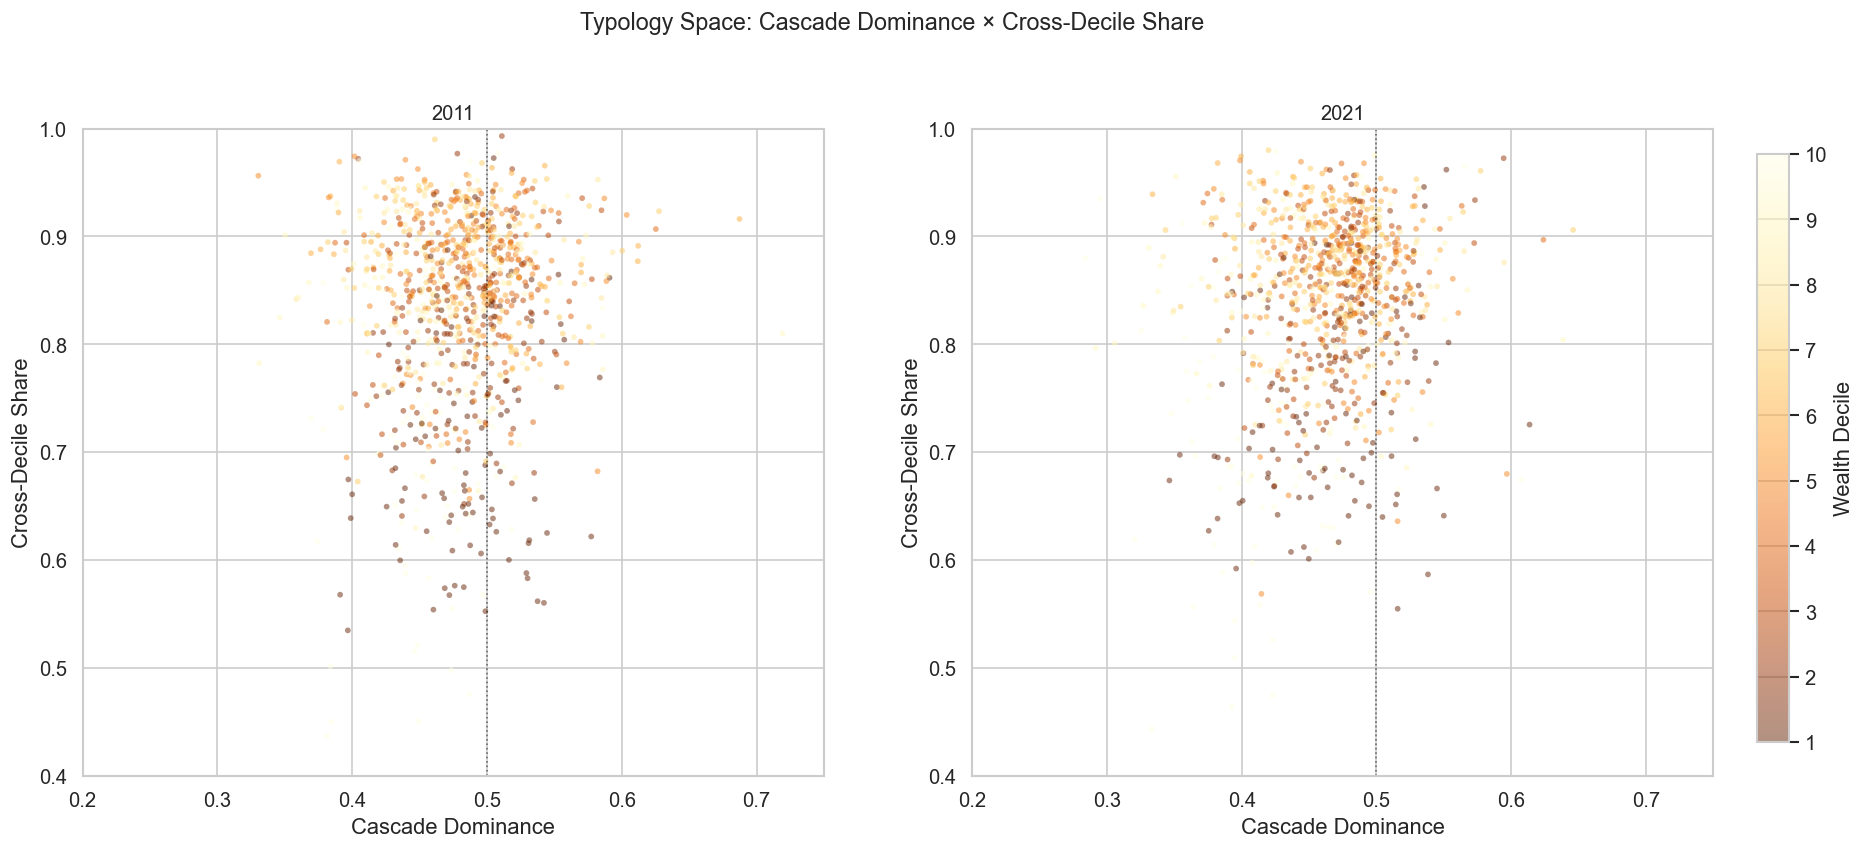


=== 2011 ===
       Cascade_Dominance_11  Cross_Decile_Share_11
count              983.0000               983.0000
mean                 0.4798                 0.8289
std                  0.0452                 0.0936
min                  0.3304                 0.4366
25%                  0.4511                 0.7825
50%                  0.4819                 0.8502
75%                  0.5066                 0.8948
max                  0.7192                 0.9932

=== 2021 ===
       Cascade_Dominance_21  Cross_Decile_Share_21
count              983.0000               983.0000
mean                 0.4638                 0.8174
std                  0.0473                 0.1459
min                  0.2841                 0.0000
25%                  0.4355                 0.7839
50%                  0.4690                 0.8527
75%                  0.4938                 0.8939
max                  0.6459                 0.9801


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    dom = f'Cascade_Dominance_{yr}'
    cds = f'Cross_Decile_Share_{yr}'
    
    scatter = ax.scatter(
        df[dom], df[cds],
        c=df['Wealth_Decile'], cmap='YlOrBr_r',
        s=12, alpha=0.5, edgecolor='none', vmin=1, vmax=10
    )
    
    ax.axvline(0.5, color='black', ls=':', lw=1, alpha=0.5, label='Dominance midline')
    ax.set_xlabel('Cascade Dominance')
    ax.set_ylabel('Cross-Decile Share')
    ax.set_title(f'20{yr}', fontsize=12)
    ax.set_xlim(0.2, 0.75)
    ax.set_ylim(0.4, 1.0)

fig.suptitle('Typology Space: Cascade Dominance × Cross-Decile Share',
             fontsize=14, y=1.02)

handles, labels = axes[0].get_legend_handles_labels()

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(scatter, cax=cbar_ax, label='Wealth Decile')

plt.savefig(OUTPUT_DIR / 'fig_12_typology_scatter_exploration.png', bbox_inches='tight')
plt.show()

for yr in ['11', '21']:
    print(f'\n=== 20{yr} ===')
    print(df[[f'Cascade_Dominance_{yr}', f'Cross_Decile_Share_{yr}']].describe().round(4).to_string())

In [ ]:
# ── 1. Cloud density: what share of MSOAs fall in the visual bulk? ──
print('── 1. Cloud Density ──')
for yr in ['11', '21']:
    dom = df[f'Cascade_Dominance_{yr}']
    cds = df[f'Cross_Decile_Share_{yr}']
    in_box = ((dom >= 0.40) & (dom <= 0.55) & (cds >= 0.75) & (cds <= 0.95)).sum()
    print(f'  20{yr}: MSOAs in Dom [0.40–0.55] × CDS [0.75–0.95]: '
          f'{in_box} / {len(df)} ({in_box/len(df)*100:.1f}%)')
 
# ── 2. CDS threshold counts ──
print('\n── 2. Cross-Decile Share Threshold Counts ──')
for yr in ['11', '21']:
    cds = df[f'Cross_Decile_Share_{yr}']
    for t in [0.70, 0.75, 0.80]:
        n = (cds >= t).sum()
        print(f'  20{yr}: CDS >= {t:.2f}: {n} ({n/len(df)*100:.1f}%)')
    print()
 
# ── 3. Leftward shift ──
print('── 3. Leftward Shift (Dom > 0.5) ──')
for yr in ['11', '21']:
    dom = df[f'Cascade_Dominance_{yr}']
    above = (dom > 0.5).sum()
    print(f'  20{yr}: Dom > 0.5: {above} ({above/len(df)*100:.1f}%)')
print(f'  Mean shift:   {df["Cascade_Dominance_11"].mean():.4f} → '
      f'{df["Cascade_Dominance_21"].mean():.4f} '
      f'(Δ = {df["Cascade_Dominance_21"].mean() - df["Cascade_Dominance_11"].mean():+.4f})')
print(f'  Median shift: {df["Cascade_Dominance_11"].median():.4f} → '
      f'{df["Cascade_Dominance_21"].median():.4f} '
      f'(Δ = {df["Cascade_Dominance_21"].median() - df["Cascade_Dominance_11"].median():+.4f})')
 
# ── 4. Dominance & CDS by Wealth Decile (both years) ──
print('\n── 4. Cascade Dominance & CDS by Wealth Decile ──')
decile_summary = (df.groupby('Wealth_Decile')
    .agg(
        n=('msoa11cd', 'size'),
        Dom_11=('Cascade_Dominance_11', 'mean'),
        Dom_21=('Cascade_Dominance_21', 'mean'),
        CDS_11=('Cross_Decile_Share_11', 'mean'),
        CDS_21=('Cross_Decile_Share_21', 'mean'),
    ).round(4))
decile_summary['Dom_Δ'] = (decile_summary['Dom_21'] - decile_summary['Dom_11']).round(4)
decile_summary['CDS_Δ'] = (decile_summary['CDS_21'] - decile_summary['CDS_11']).round(4)
print(decile_summary.to_string())
 
# ── 5. Low-CDS outliers ──
print('\n── 5. Low-CDS Outliers (CDS < 0.50) ──')
for yr in ['11', '21']:
    low = df[df[f'Cross_Decile_Share_{yr}'] < 0.50]
    print(f'  20{yr}: {len(low)} MSOAs')
    if len(low) > 0:
        vc = low['Wealth_Decile'].value_counts().sort_index()
        print(f'    Decile distribution: {dict(vc)}')
 
# ── 6. Axis independence ──
print('\n── 6. Axis Independence (Spearman: Dom vs CDS) ──')
for yr in ['11', '21']:
    rho, p = stats.spearmanr(
        df[f'Cascade_Dominance_{yr}'], df[f'Cross_Decile_Share_{yr}'])
    print(f'  20{yr}: ρ = {rho:.3f}, p = {p:.2e}')

── 1. Cloud Density ──
  2011: MSOAs in Dom [0.40–0.55] × CDS [0.75–0.95]: 702 / 983 (71.4%)
  2021: MSOAs in Dom [0.40–0.55] × CDS [0.75–0.95]: 694 / 983 (70.6%)

── 2. Cross-Decile Share Threshold Counts ──
  2011: CDS >= 0.70: 880 (89.5%)
  2011: CDS >= 0.75: 809 (82.3%)
  2011: CDS >= 0.80: 700 (71.2%)

  2021: CDS >= 0.70: 871 (88.6%)
  2021: CDS >= 0.75: 806 (82.0%)
  2021: CDS >= 0.80: 694 (70.6%)

── 3. Leftward Shift (Dom > 0.5) ──
  2011: Dom > 0.5: 319 (32.5%)
  2021: Dom > 0.5: 184 (18.7%)
  Mean shift:   0.4798 → 0.4638 (Δ = -0.0160)
  Median shift: 0.4819 → 0.4690 (Δ = -0.0129)

── 4. Cascade Dominance & CDS by Wealth Decile ──
                n  Dom_11  Dom_21  CDS_11  CDS_21   Dom_Δ   CDS_Δ
Wealth_Decile                                                    
1              99  0.4869  0.4687  0.7146  0.7131 -0.0182 -0.0015
2              98  0.4822  0.4722  0.8112  0.8017 -0.0100 -0.0095
3              98  0.4791  0.4692  0.8488  0.8230 -0.0099 -0.0258
4              98  0

### Fig 12 Interpretation

This plot pairs Dominance with Cross-Decile Share (proportion of all migration that crosses a decile boundary in either direction).

From this plot, we can test if an individual MSOA's migration is fundamentally about socioeconomic restructuring, or is most of it within-tier. -- **share of migration that involves any cross-decile movement.**
- An MSOA can have high cross-decile share but with 0.5 dominance. This means lots of deprivation-crossing movement but perfectly balanced between up and down.

- **The dominant pattern is a dense, continuous cloud, not discrete clusters.**
    - The bulk of MSOAs sit beterrn roughly 0.4-0.55 on dominance and 0.75-0.95 on cross-decile share.
    - **Most London neighbourhoods have high rates of socioeconomic restructuring through migration** (in 88.6% MSOAs in 2021, at least 70% of migration flows cross a deprivation decile boundary)
        - **Socioeconomic restructuring through migration is the norm rather than the exception.**
    - For most of above neighbourhoods, **the directional balance between cascade and counter-cascade is farily close to even, though tilted slightly counter-cascade-ward**, since the cloud centre sits left of the 0.5 midline.
- **The leftward shift from 2011 and 2021.** (similar results in fig 10)
    - MSOAs with cascade dominance >0.5 dropped (32.5% in 2011 to 18.7% in 2021)
    - The mean dominance droppedn (0.48 in 2011 to 0.464 in 2021)
    - **Across London, counter-cascade flows became relatively more prevalent.**
- There is a deprivation-position effect in both 2011 and 2021.
    - In 2021, **Wealthiest MSOAs** (D10) sit further left with a mean dominance of 0.425 -- **disproportionately export residents to more deprived areas**, rather than receiving from them.
    - Most deprived MSOAs sit closer to the midline at 0.469 in 2021.
    - In 2011, the gap between Decile 1 (0.487) and Decile 10 (0.455) is only about 0.03, whereas in 2021, this widens slightly to 0.04 (0.469 vs. 0.425) 
    - The wealthiest areas have limited "upward" room in the hierarchy, so the cross-decile flows are naturally counter-dominated.
- **The y-axis reveals a U-shaped by deprivation in both 2011 and 2021.**
    - Both the most deprived and most affluent MSOAs have the lowest cross-decile shares (clearer pattern in 2021), while mid-tier neighbourhoods (D4-D8) cluster around 0.84-0.87.
    - This aligns with the right above finding, where areas at the extremes of the hierarchy have fewer "available" decile boundaries to cross, so a larger share of its flows are lateral within the bottom tiers.
- **Low Cross-Decile (<0.5) increased in 2021 from 2011.**
    - In 2011, all MSOAs with CDS below 0.5 were in Decile 10.
        - These are the wealthiest areas where lateral migration is a celling effect.
    - By 2021, 23 MSOAs with CDS below 0.5, scattered across Decile 1-7 and 10.
        - **Emergence of low-CDS areas across the deprivation spectrum in 2021.**
- **Two axes are uncorrelated (rho=0.08).**
    - Two metrics capture genuienly independent dimensions of the flow regime,
    - This supports using both axes jointly for the typology rather than replying on either alone.

---
## 14. Typology Construction

Based on the scatter exploration, we define thresholds. 

The initial approach uses the natural midline (0.50) for Cascade_Dominance and a percentile-based threshold for Cross_Decile_Share.

In [17]:
def assign_typology(row, yr='21',
                    dom_upper=0.52, dom_lower=0.48,
                    cds_threshold=None):
    """
    Classify MSOA into flow regime typology.
    
    Parameters
    ----------
    dom_upper, dom_lower : float
        Cascade_Dominance thresholds. 
        > dom_upper → cascade-led; < dom_lower → counter-led; between → symmetric
    cds_threshold : float
        Cross_Decile_Share below this → lateral-dominated.
        Default: 25th percentile of CDS distribution.
    """
    dom = row[f'Cascade_Dominance_{yr}']
    cds = row[f'Cross_Decile_Share_{yr}']
    
    if cds < cds_threshold:
        return 'Lateral'
    elif dom > dom_upper:
        return 'Cascade-led'
    elif dom < dom_lower:
        return 'Counter-led'
    else:
        return 'Symmetric'

# Compute threshold (25th percentile of Cross_Decile_Share)
cds_p25 = df['Cross_Decile_Share_21'].quantile(0.25)
print(f'Cross_Decile_Share 25th percentile (2021): {cds_p25:.4f}')

# Apply typology
df['Typology_21'] = df.apply(
    assign_typology, axis=1, yr='21', cds_threshold=cds_p25
)

# Also for 2011
cds_p25_11 = df['Cross_Decile_Share_11'].quantile(0.25)
df['Typology_11'] = df.apply(
    assign_typology, axis=1, yr='11', cds_threshold=cds_p25_11
)

print(f'\n=== Typology Distribution (2021) ===')
print(df['Typology_21'].value_counts().to_string())
print(f'\n=== Typology Distribution (2011) ===')
print(df['Typology_11'].value_counts().to_string())

Cross_Decile_Share 25th percentile (2021): 0.7839

=== Typology Distribution (2021) ===
Typology_21
Counter-led    423
Lateral        246
Symmetric      242
Cascade-led     72

=== Typology Distribution (2011) ===
Typology_11
Counter-led    340
Symmetric      267
Lateral        246
Cascade-led    130


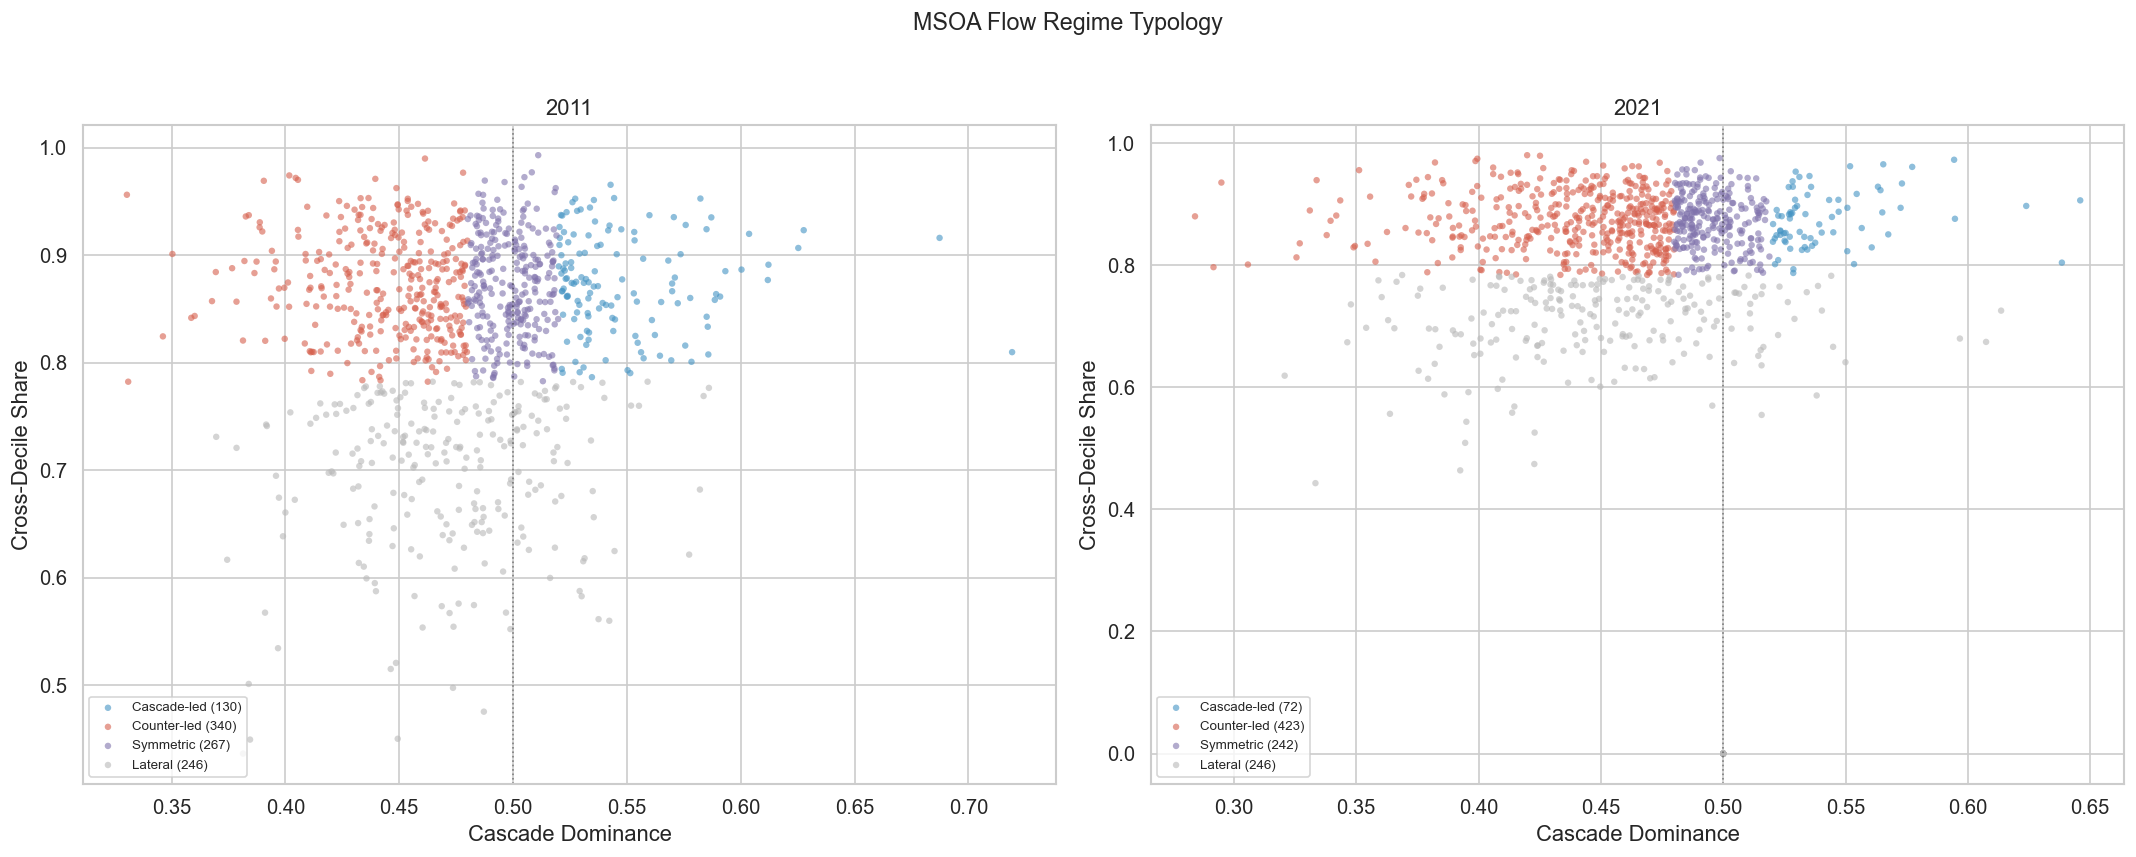

In [18]:
# ── Typology scatter — coloured by type ───────────────────────
TYPOLOGY_COLORS = {
    'Cascade-led':  '#4393c3',   # cool blue — downward pressure
    'Counter-led':  '#d6604d',   # warm coral — upward mobility
    'Symmetric':    '#8073ac',   # muted purple — balanced
    'Lateral':      '#b8b8b8',   # grey — insulated
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    dom = f'Cascade_Dominance_{yr}'
    cds = f'Cross_Decile_Share_{yr}'
    typ = f'Typology_{yr}'
    
    for tname, tcolor in TYPOLOGY_COLORS.items():
        mask = df[typ] == tname
        ax.scatter(df.loc[mask, dom], df.loc[mask, cds],
                   c=tcolor, s=15, alpha=0.6, edgecolor='none',
                   label=f'{tname} ({mask.sum()})')
    
    ax.axvline(0.5, color='black', ls=':', lw=1, alpha=0.4)
    ax.set_xlabel('Cascade Dominance')
    ax.set_ylabel('Cross-Decile Share')
    ax.set_title(f'20{yr}')
    ax.legend(fontsize=8, loc='lower left')

fig.suptitle('MSOA Flow Regime Typology', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_13_typology_scatter_classified.png')
plt.show()

---
## 15. Typology — Diagnostic Map

/Users/xing/Desktop/CASA/dissertation/script/map_utils.py:210: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/script/map_utils.py:210: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/script/map_utils.py:210: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title=column)
/Users/xing/Desktop/CASA/dissertation/script/ma

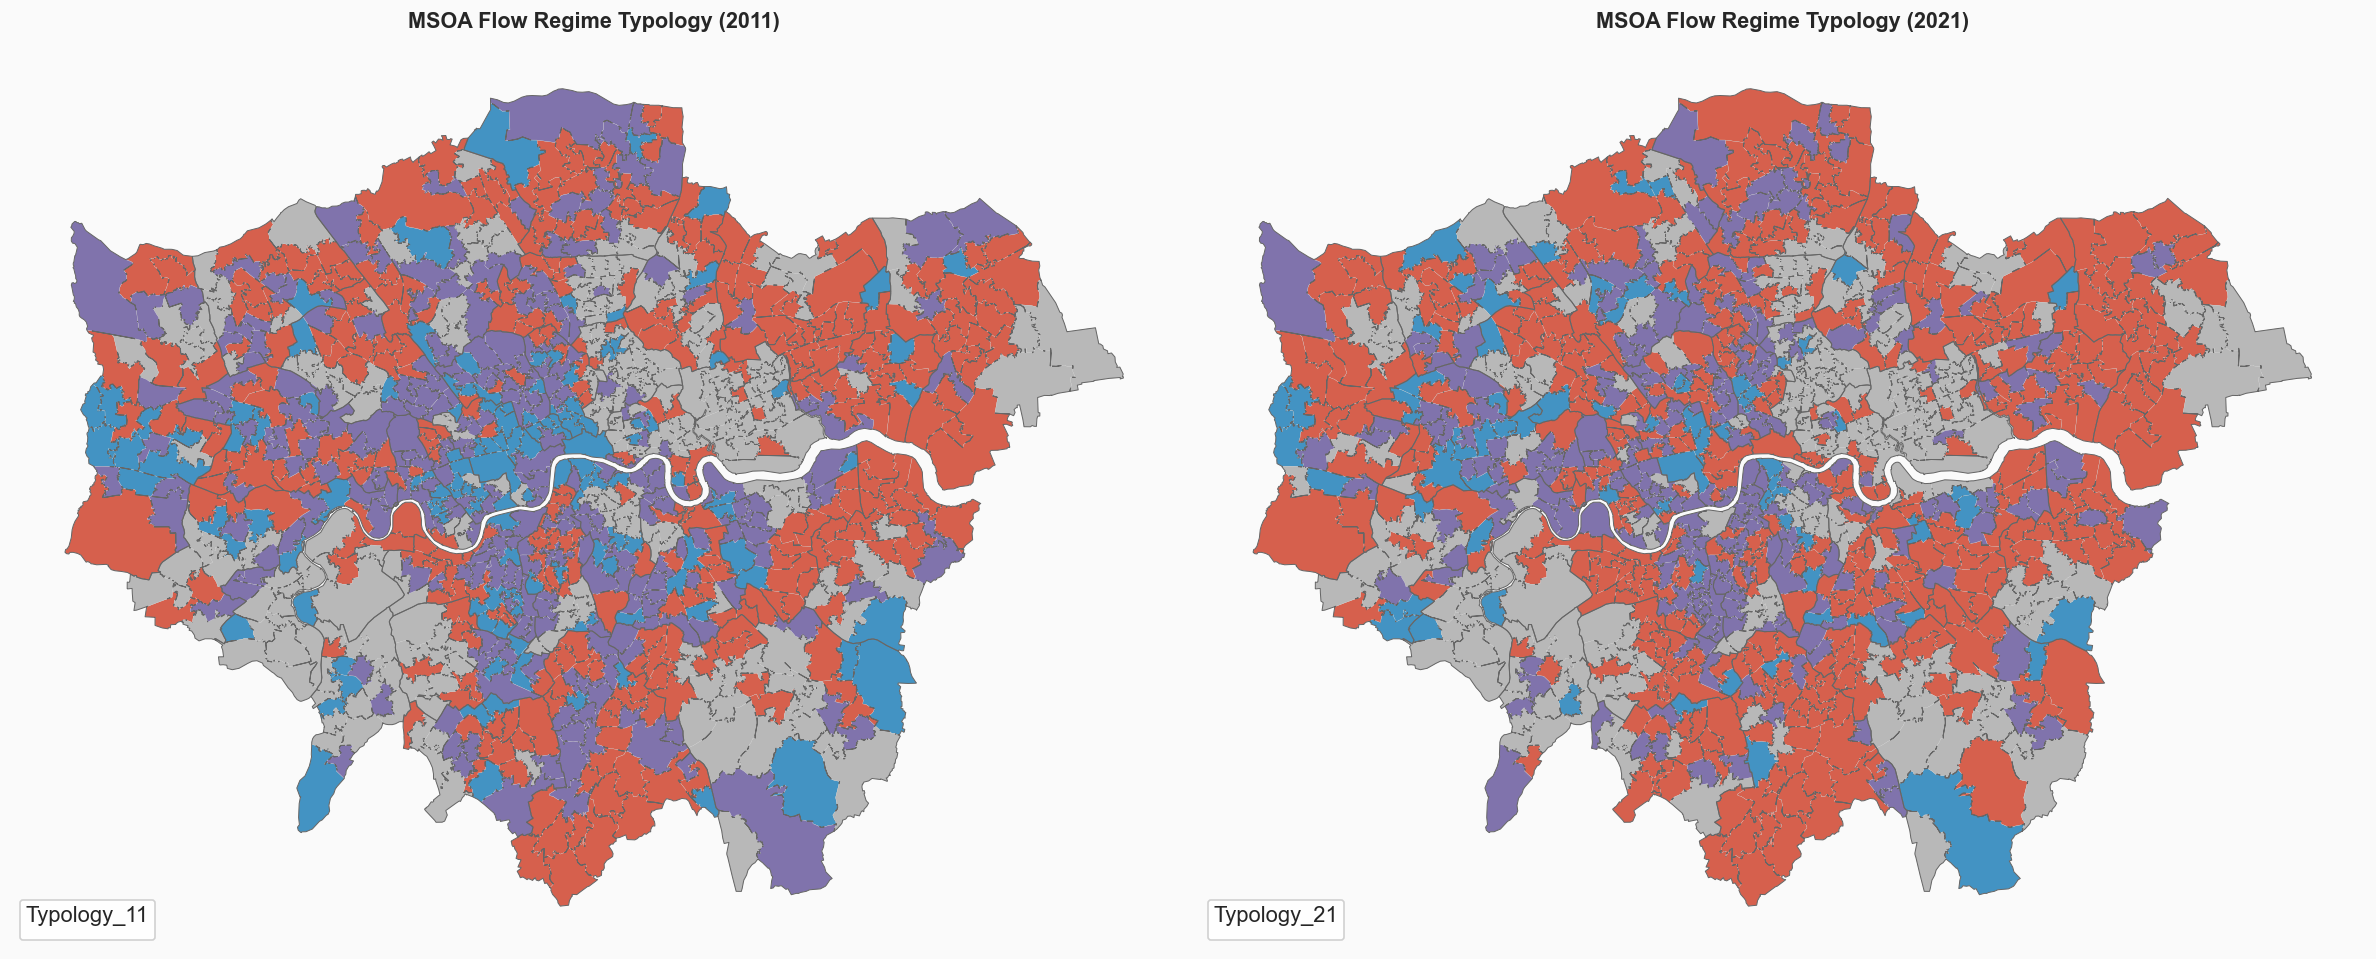

In [19]:
gdf = load_london_msoa(GEO_PATH, df)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for idx, yr in enumerate(['11', '21']):
    ax = axes[idx]
    plot_london_categorical(
        gdf, column=f'Typology_{yr}',
        title=f'MSOA Flow Regime Typology (20{yr})',
        color_dict=TYPOLOGY_COLORS,
        ax=ax
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_14_typology_map.png')
plt.show()

---
## 16. Typology Profiles

For each type: mean metrics, decile composition, borough composition.

In [20]:
# ── Mean metrics per typology ──────────────────────────────────
profile_cols = [
    'CFI_Churn_21', 'Counter_Churn_21', 'Net_Cascade_21', 'Net_Counter_21',
    'CFI_Rate_21', 'Counter_Rate_21',
    'Pct_Inflow_Wealthier_21', 'Pct_Outflow_Wealthier_21',
    'Cascade_Dominance_21', 'Cross_Decile_Share_21',
    'Total_Migration_21', 'IMD_Pctile_Change'
]

print('=== Mean Metric Values by Typology (2021) ===')
profile = df.groupby('Typology_21')[profile_cols].mean().round(2)
print(profile.T.to_string())

=== Mean Metric Values by Typology (2021) ===
Typology_21               Cascade-led  Counter-led  Lateral  Symmetric
CFI_Churn_21                   688.01       525.99   423.82     697.09
Counter_Churn_21               576.44       658.71   501.59     711.37
Net_Cascade_21                 -29.76       -19.60    58.56     -16.41
Net_Counter_21                 -19.00       -39.07    69.43       3.36
CFI_Rate_21                     40.69        37.05    16.42      53.36
Counter_Rate_21                 32.93        58.12    21.05      57.82
Pct_Inflow_Wealthier_21         45.52        35.12    30.47      41.85
Pct_Outflow_Wealthier_21        43.64        42.95    33.24      43.74
Cascade_Dominance_21             0.54         0.44     0.45       0.50
Cross_Decile_Share_21            0.88         0.87     0.65       0.87
Total_Migration_21            1451.82      1360.77  1304.11    1613.16
IMD_Pctile_Change               -0.01        -0.02     0.03       0.01


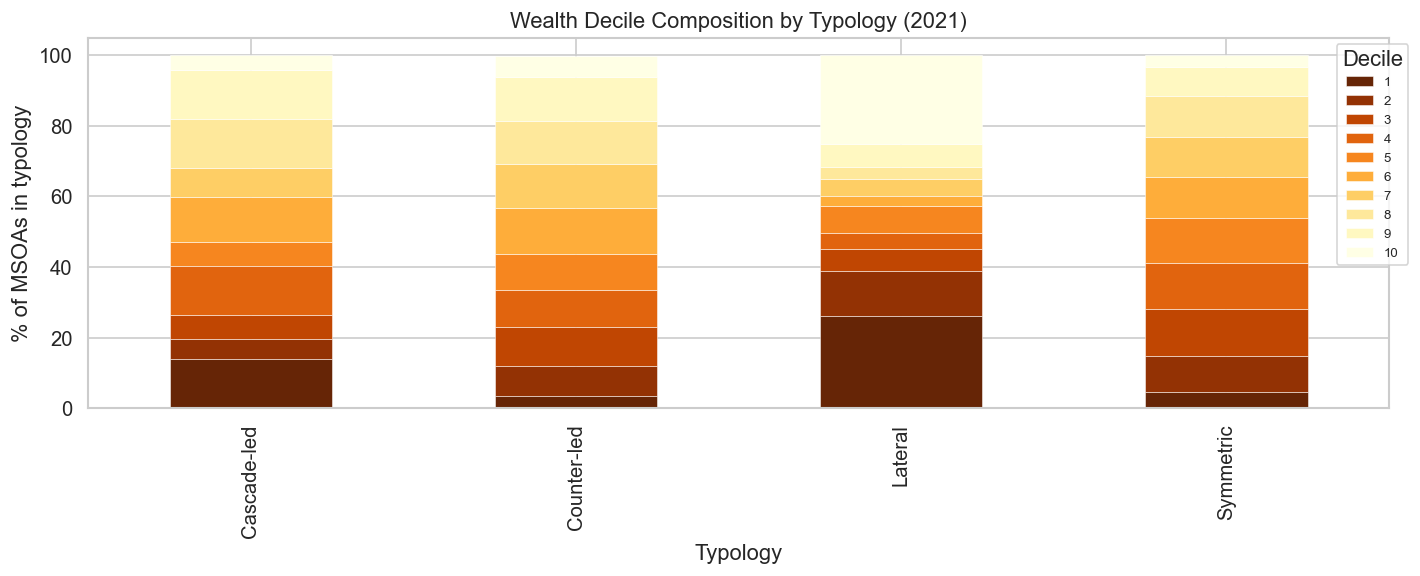

In [21]:
# ── Decile composition per typology ────────────────────────────
ct_decile = pd.crosstab(df['Typology_21'], df['Wealth_Decile'], normalize='index')
ct_decile = (ct_decile * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
ct_decile.plot(kind='bar', stacked=True, cmap='YlOrBr_r', ax=ax, edgecolor='white', lw=0.3)
ax.set_xlabel('Typology')
ax.set_ylabel('% of MSOAs in typology')
ax.set_title('Wealth Decile Composition by Typology (2021)')
ax.legend(title='Decile', bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_15_typology_decile_composition.png')
plt.show()

In [22]:
# ── Top boroughs per typology ──────────────────────────────────
print('=== Top 5 Boroughs per Typology (2021) ===')
for typ in ['Cascade-led', 'Counter-led', 'Symmetric', 'Lateral']:
    subset = df[df['Typology_21'] == typ]
    top = subset['ladnm'].value_counts().head(5)
    print(f'\n{typ} ({len(subset)} MSOAs):')
    for borough, count in top.items():
        print(f'  {borough}: {count}')

=== Top 5 Boroughs per Typology (2021) ===

Cascade-led (72 MSOAs):
  Ealing: 9
  Barnet: 7
  Southwark: 7
  Harrow: 4
  Hillingdon: 4

Counter-led (423 MSOAs):
  Croydon: 34
  Enfield: 23
  Havering: 23
  Redbridge: 22
  Brent: 20

Symmetric (242 MSOAs):
  Lambeth: 20
  Ealing: 17
  Wandsworth: 16
  Camden: 13
  Barnet: 11

Lateral (246 MSOAs):
  Newham: 30
  Hackney: 22
  Tower Hamlets: 18
  Richmond upon Thames: 15
  Bromley: 14


---
## Phase F — Does the Typology Predict Deprivation Change?

IMD_Pctile_Change is the external validation, constructed independently from the cascade metrics. Positive = moved up in national ranking = less deprived.

---
## 17. Correlation with IMD_Pctile_Change

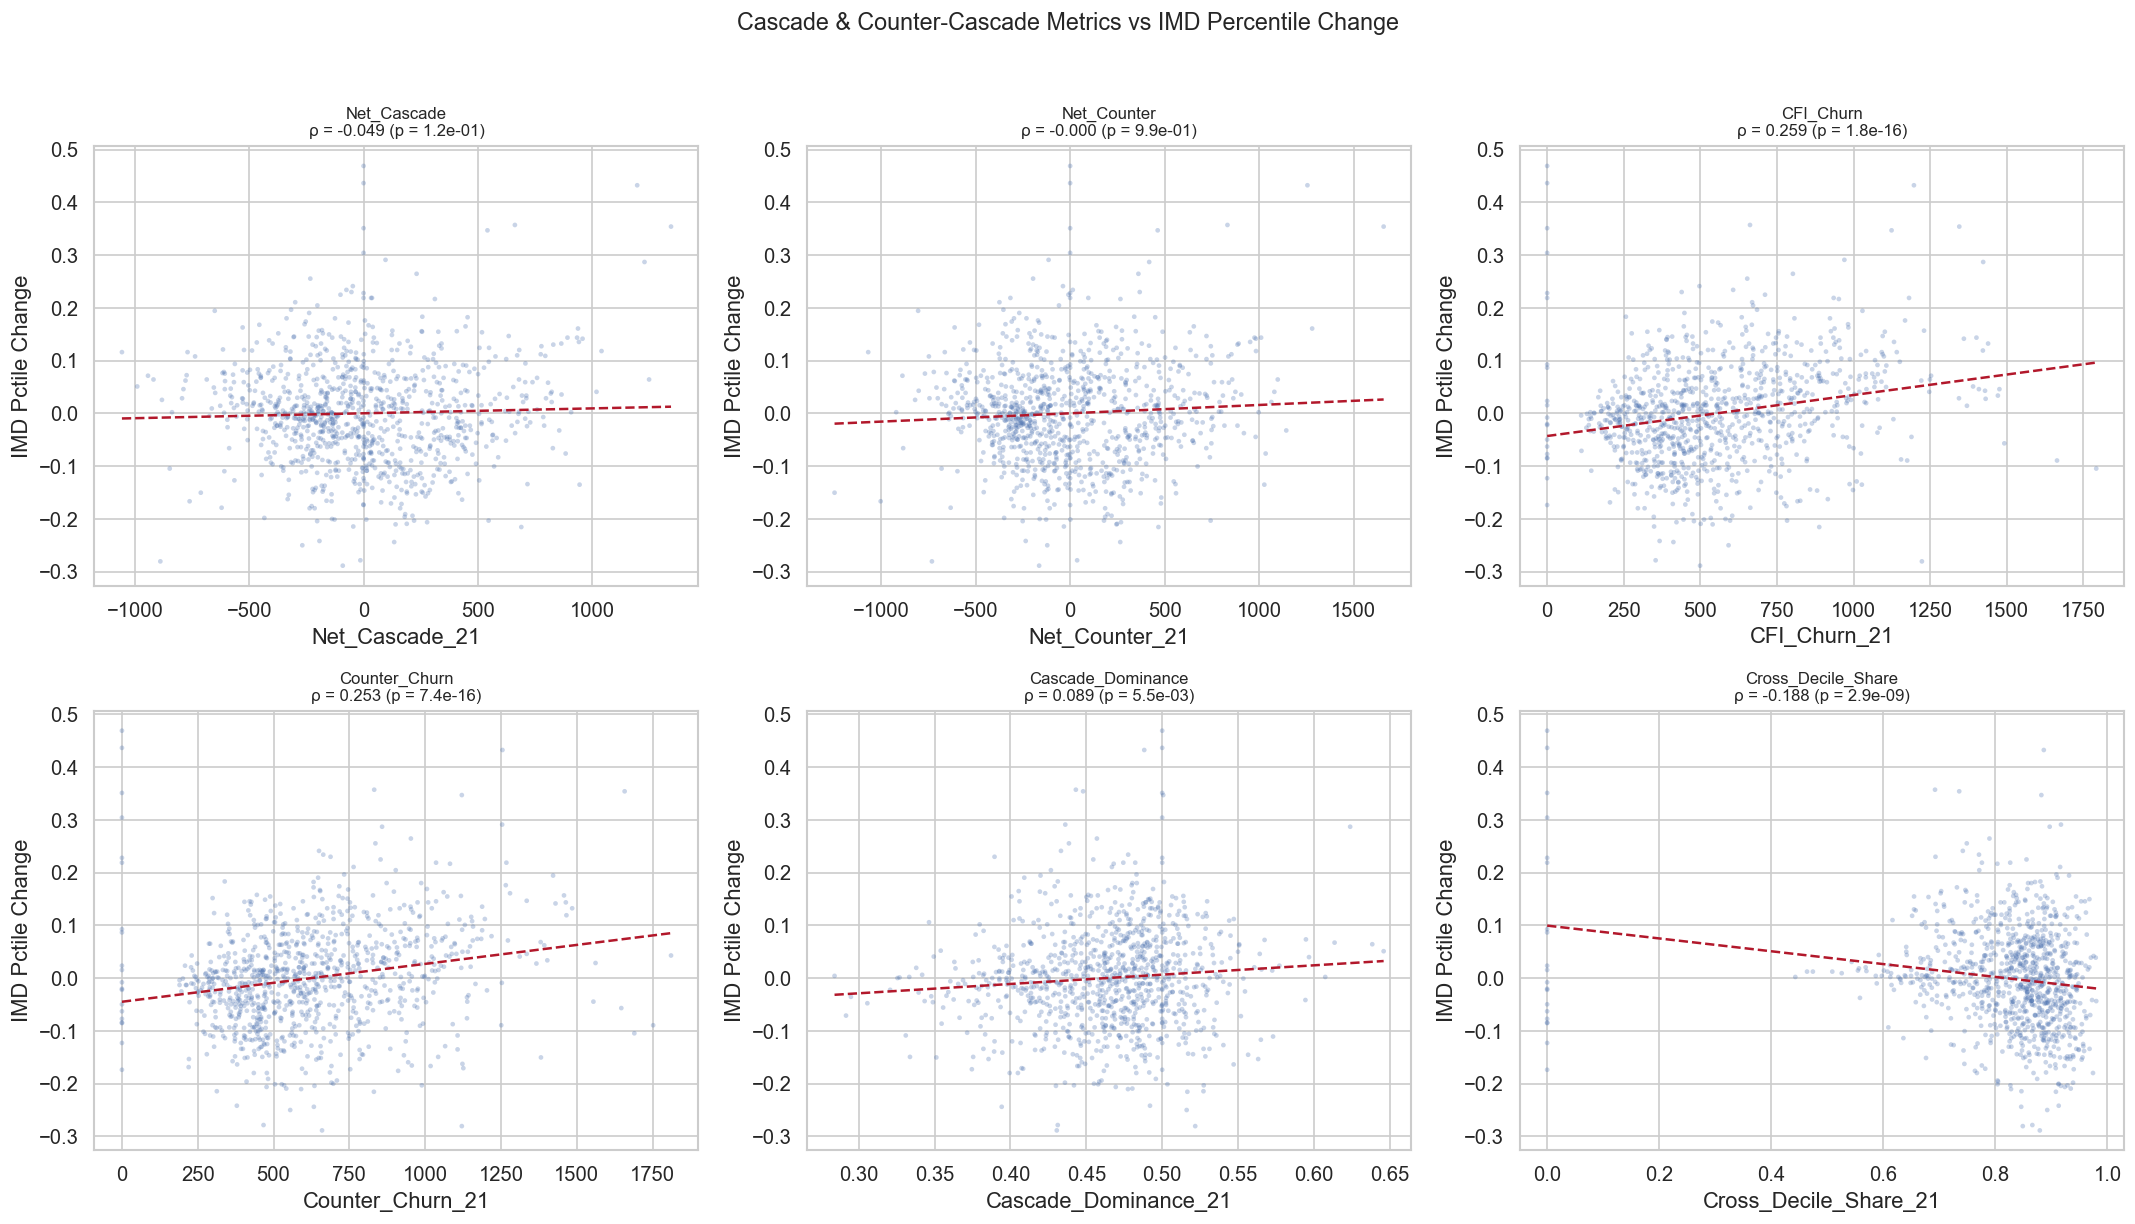

In [23]:
# ── Scatterplots: key metrics vs IMD_Pctile_Change ────────────
validation_metrics = [
    'Net_Cascade_21', 'Net_Counter_21',
    'CFI_Churn_21', 'Counter_Churn_21',
    'Cascade_Dominance_21', 'Cross_Decile_Share_21'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(validation_metrics):
    ax = axes.flatten()[i]
    ax.scatter(df[col], df['IMD_Pctile_Change'], s=8, alpha=0.3, edgecolor='none')
    
    # Spearman correlation
    rho, pval = stats.spearmanr(df[col], df['IMD_Pctile_Change'])
    ax.set_title(f'{col.replace("_21", "")}\nρ = {rho:.3f} (p = {pval:.1e})',
                 fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('IMD Pctile Change')
    
    # Regression line
    z = np.polyfit(df[col], df['IMD_Pctile_Change'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color='#b2182b', lw=1.5, ls='--')

fig.suptitle('Cascade & Counter-Cascade Metrics vs IMD Percentile Change',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_16_validation_scatters.png')
plt.show()

In [24]:
# ── Partial correlations (controlling for Wealth_Decile) ──────
from scipy.stats import spearmanr

def partial_spearman(x, y, z):
    """Partial Spearman correlation of x and y, controlling for z."""
    # Rank-based: correlate residuals from regressing ranks on z
    from numpy.polynomial.polynomial import polyfit, polyval
    rx, ry, rz = stats.rankdata(x), stats.rankdata(y), stats.rankdata(z)
    # Residualize x and y on z
    cx = np.polyfit(rz, rx, 1)
    cy = np.polyfit(rz, ry, 1)
    resid_x = rx - np.polyval(cx, rz)
    resid_y = ry - np.polyval(cy, rz)
    return stats.spearmanr(resid_x, resid_y)

print('Validation: Spearman ρ with IMD_Pctile_Change')
print('=' * 70)
print(f'{"Metric":>28s} {"Raw ρ":>10s} {"Partial ρ":>10s} {"(ctrl W.D.)":>12s}')
print('─' * 70)

for col in validation_metrics:
    rho_raw, p_raw = stats.spearmanr(df[col], df['IMD_Pctile_Change'])
    rho_part, p_part = partial_spearman(df[col], df['IMD_Pctile_Change'], df['Wealth_Decile'])
    print(f'{col.replace("_21",""):>28s} {rho_raw:>+10.3f} {rho_part:>+10.3f} {"(p=" + f"{p_part:.1e}" + ")":>12s}')

Validation: Spearman ρ with IMD_Pctile_Change
                      Metric      Raw ρ  Partial ρ  (ctrl W.D.)
──────────────────────────────────────────────────────────────────────
                 Net_Cascade     -0.049     -0.238  (p=4.4e-14)
                 Net_Counter     -0.000     -0.215  (p=9.0e-12)
                   CFI_Churn     +0.259     +0.232  (p=1.6e-13)
               Counter_Churn     +0.253     +0.229  (p=3.4e-13)
           Cascade_Dominance     +0.089     +0.065  (p=4.2e-02)
          Cross_Decile_Share     -0.188     -0.170  (p=8.2e-08)


---
## 18. Typology vs IMD Percentile Change

The ultimate validation: does the typology separate neighbourhoods with
different deprivation trajectories?

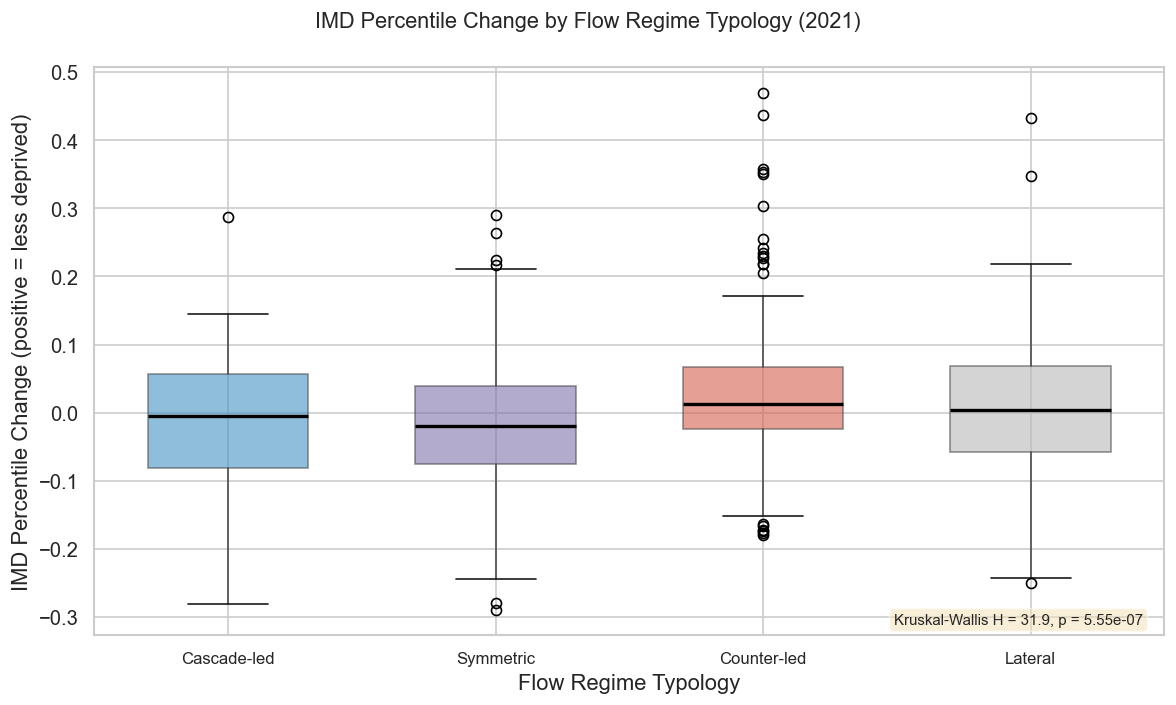

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

order = ['Cascade-led', 'Symmetric', 'Counter-led', 'Lateral']
colors = [TYPOLOGY_COLORS[t] for t in order]

bp = df.boxplot(column='IMD_Pctile_Change', by='Typology_21',
                positions=range(len(order)), ax=ax, patch_artist=True,
                return_type='dict', widths=0.6)

# Style the boxes
for i, (box, median) in enumerate(zip(bp['IMD_Pctile_Change']['boxes'],
                                       bp['IMD_Pctile_Change']['medians'])):
    box.set_facecolor(colors[i])
    box.set_alpha(0.6)
    median.set_color('black')
    median.set_linewidth(2)

ax.set_xticklabels(order, fontsize=10)
ax.set_xlabel('Flow Regime Typology')
ax.set_ylabel('IMD Percentile Change (positive = less deprived)')
ax.set_title('')
fig.suptitle('IMD Percentile Change by Flow Regime Typology (2021)', fontsize=13)

# Kruskal-Wallis test
groups = [df.loc[df['Typology_21'] == t, 'IMD_Pctile_Change'].values for t in order]
kw_stat, kw_p = stats.kruskal(*groups)
ax.annotate(f'Kruskal-Wallis H = {kw_stat:.1f}, p = {kw_p:.2e}',
            xy=(0.98, 0.02), xycoords='axes fraction', ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_17_typology_vs_imd_boxplot.png')
plt.show()

---
## 19. Export Typology Labels

In [26]:
# Export typology labels for downstream use (File 4 + 5)
export_cols = ['msoa11cd', 'ladnm', 'Wealth_Decile',
               'Typology_11', 'Typology_21',
               'Cascade_Dominance_21', 'Cross_Decile_Share_21',
               'IMD_Pctile_Change', 'Sign_Concordance_21']

export_df = df[export_cols].copy()
export_path = DATA_DIR / 'msoa_typology_labels.csv'
export_df.to_csv(export_path, index=False)

print(f'Typology labels exported: {export_path}')
print(f'Shape: {export_df.shape}')
print(f'\nTypology (2021):')
print(export_df['Typology_21'].value_counts().to_string())

Typology labels exported: /Users/xing/Desktop/CASA/dissertation/outputs/msoa_typology_labels.csv
Shape: (983, 9)

Typology (2021):
Typology_21
Counter-led    423
Lateral        246
Symmetric      242
Cascade-led     72


---
## 20. Summary

### Phase E findings
- The typology space (Cascade_Dominance × Cross_Decile_Share) produces
  four interpretable flow regime types.
- Threshold sensitivity: the classification depends on the dominance bandwidth
  (±0.02 from 0.50) and the CDS percentile cutoff (25th). These should be
  tested for robustness.

### Phase F findings
- IMD_Pctile_Change validation: [to be filled after running]
- Partial correlations controlling for Wealth_Decile reveal which metrics
  carry information beyond hierarchy position.
- Typology boxplot: if the Kruskal-Wallis test is significant, the typology
  adds explanatory value for deprivation trajectories.

### Output
`msoa_typology_labels.csv` — consumed by File 4 (spatial synthesis) and
File 5 (case studies).

---
*Next: `eda_4_spatial_synthesis.ipynb` (Phase G)*